In [1]:
import json
import pandas as pd
from pathlib import Path

In [4]:
methods = ['DWT-DCT', 'LBS', 'MBRS', 'VINE']

results_data = {}
for method in methods:
    file_path = Path(f'./results/{method}_benchmark_results.json')
    if file_path.exists():
        with open(file_path, 'r') as f:
            results_data[method] = json.load(f)
        print(f"Loaded {method}: {len(results_data[method])} entries")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nTotal methods loaded: {len(results_data)}")

Loaded DWT-DCT: 235 entries
Loaded LBS: 235 entries
Loaded MBRS: 235 entries
Loaded VINE: 141 entries

Total methods loaded: 4


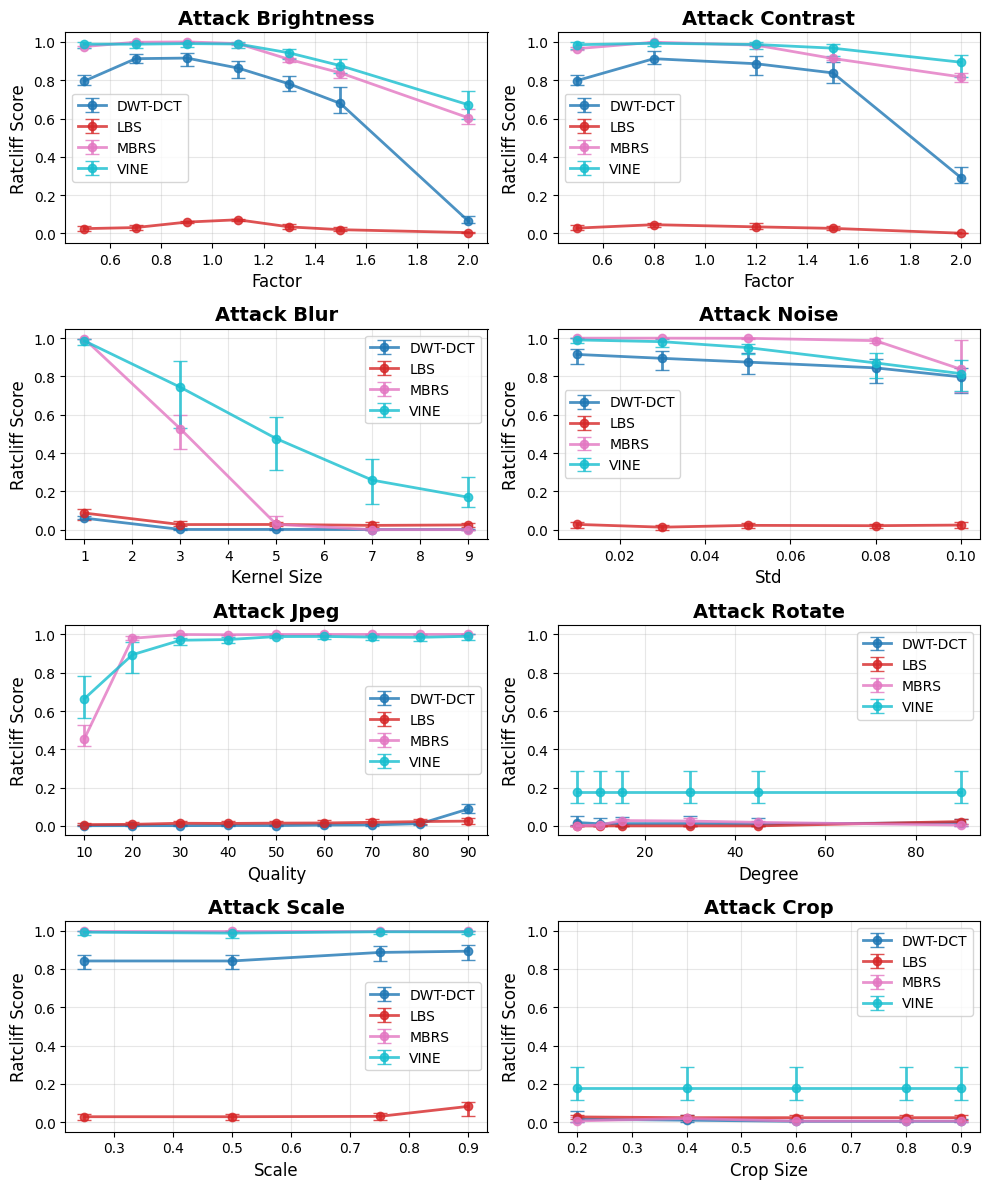

Plot saved as 'watermark_robustness_analysis.png'


In [5]:
import matplotlib.pyplot as plt
import numpy as np

attack_types = {
    'attack_brightness': 'factor',
    'attack_contrast': 'factor',
    'attack_blur': 'kernel_size',
    'attack_noise': 'std',
    'attack_jpeg': 'quality',
    'attack_rotate': 'degree',
    'attack_scale': 'scale',
    'attack_crop': 'crop_size'
}

organized_data = {attack: {method: {} for method in methods} for attack in attack_types}

for method, data in results_data.items():
    for entry in data:
        attack = entry['attacks']
        if attack is None:
            continue
        
        attack_name = attack[0]
        if attack_name in attack_types:
            attack_params = attack[1]
            param_name = attack_types[attack_name]
            magnitude = attack_params[param_name]
            
            ratcliff_mean = entry['results']['avg_ratcliff_obershelp_scores']
            
            if ratcliff_mean is None:
                continue
            
            if magnitude not in organized_data[attack_name][method]:
                organized_data[attack_name][method][magnitude] = []
            
            organized_data[attack_name][method][magnitude].append(ratcliff_mean)

aggregated_data = {attack: {method: [] for method in methods} for attack in attack_types}

for attack in attack_types:
    for method in methods:
        for magnitude, values in organized_data[attack][method].items():
            if values:
                mean_val = np.mean(values)
                min_val = np.min(values)
                max_val = np.max(values)
                
                aggregated_data[attack][method].append({
                    'magnitude': magnitude,
                    'mean': mean_val,
                    'lower_err': mean_val - min_val,
                    'upper_err': max_val - mean_val
                })
        
        aggregated_data[attack][method] = sorted(
            aggregated_data[attack][method], 
            key=lambda x: x['magnitude']
        )

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = {method: colors[i] for i, method in enumerate(methods)}

for idx, (attack_name, param_name) in enumerate(attack_types.items()):
    ax = axes[idx]
    
    for method in methods:
        data_points = aggregated_data[attack_name][method]
        
        if not data_points:
            continue
        
        magnitudes = [d['magnitude'] for d in data_points]
        means = [d['mean'] for d in data_points]
        lower_errs = [d['lower_err'] for d in data_points]
        upper_errs = [d['upper_err'] for d in data_points]
        
        yerr = [lower_errs, upper_errs]
        ax.errorbar(magnitudes, means, yerr=yerr, 
                   label=method, marker='o', capsize=5, 
                   linewidth=2, markersize=6, 
                   color=method_colors[method], alpha=0.8)
    
    ax.set_xlabel(f'{param_name.replace("_", " ").title()}', fontsize=12)
    ax.set_ylabel('Ratcliff Score', fontsize=12)
    ax.set_title(f'{attack_name.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    ax.set_ylim(-0.05, 1.05)

# plt.suptitle('Watermark Robustness Analysis (Mean across messages, Min/Max as error bars)', 
#              fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('watermark_robustness_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'watermark_robustness_analysis.png'")

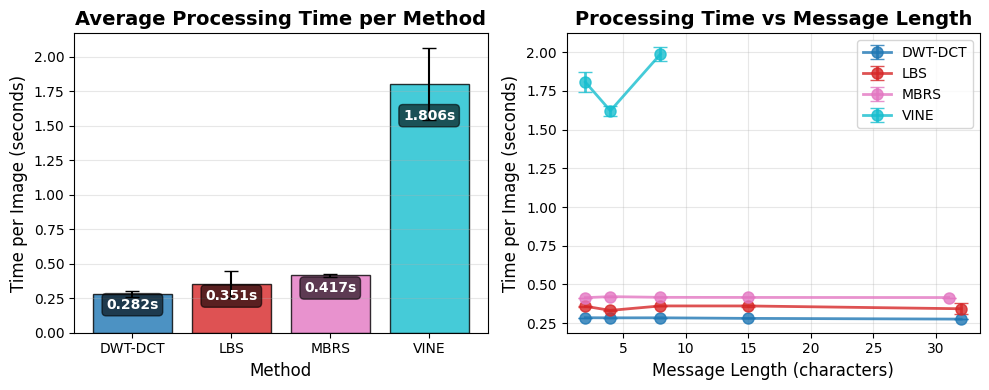

Time analysis plot saved as 'watermark_time_analysis.png'


In [6]:
import matplotlib.pyplot as plt
import numpy as np

time_data = {method: [] for method in methods}
time_by_message = {method: {} for method in methods}

for method, data in results_data.items():
    for entry in data:
        time_val = entry['results']['time_per_image_sec']
        message = entry['message']
        
        if time_val is not None:
            time_data[method].append(time_val)
            
            if message not in time_by_message[method]:
                time_by_message[method][message] = []
            time_by_message[method][message].append(time_val)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax1 = axes[0]
avg_times = [np.mean(time_data[method]) if time_data[method] else 0 for method in methods]
std_times = [np.std(time_data[method]) if time_data[method] else 0 for method in methods]

colors_bar = plt.cm.tab10(np.linspace(0, 1, len(methods)))
bars = ax1.bar(methods, avg_times, yerr=std_times, capsize=5, 
               color=colors_bar, alpha=0.8, edgecolor='black')

ax1.set_ylabel('Time per Image (seconds)', fontsize=12)
ax1.set_xlabel('Method', fontsize=12)
ax1.set_title('Average Processing Time per Method', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, avg in zip(bars, avg_times):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height * 0.9,
             f'{avg:.3f}s', ha='center', va='top', fontsize=10, fontweight='bold',
             color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6))

ax2 = axes[1]
message_lengths = sorted(set(msg for method_data in time_by_message.values() 
                            for msg in method_data.keys()), 
                        key=lambda x: len(x))

colors_line = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = {method: colors_line[i] for i, method in enumerate(methods)}

for method in methods:
    msg_lens = []
    avg_times_by_len = []
    std_times_by_len = []
    
    for msg in message_lengths:
        if msg in time_by_message[method] and time_by_message[method][msg]:
            msg_lens.append(len(msg))
            avg_times_by_len.append(np.mean(time_by_message[method][msg]))
            std_times_by_len.append(np.var(time_by_message[method][msg]))
    
    if msg_lens:
        ax2.errorbar(msg_lens, avg_times_by_len, yerr=std_times_by_len,
                    marker='o', label=method, capsize=5,
                    linewidth=2, markersize=8, color=method_colors[method], alpha=0.8)

ax2.set_xlabel('Message Length (characters)', fontsize=12)
ax2.set_ylabel('Time per Image (seconds)', fontsize=12)
ax2.set_title('Processing Time vs Message Length', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('watermark_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Time analysis plot saved as 'watermark_time_analysis.png'")

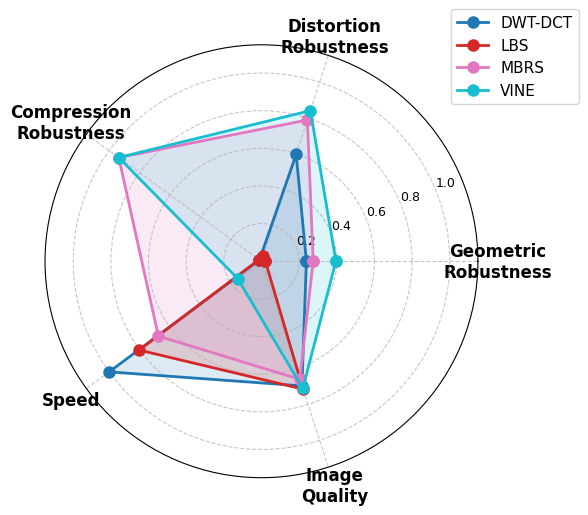

Spider plot saved as 'watermark_spider_plot.png'

Final scores by method:

DWT-DCT:
  Geometric Robustness: 0.239
  Distortion Robustness: 0.597
  Compression Robustness: 0.013
  Speed: 1.000
  Image Quality: 0.696

LBS:
  Geometric Robustness: 0.021
  Distortion Robustness: 0.031
  Compression Robustness: 0.015
  Speed: 0.803
  Image Quality: 0.715

MBRS:
  Geometric Robustness: 0.275
  Distortion Robustness: 0.789
  Compression Robustness: 0.937
  Speed: 0.677
  Image Quality: 0.660

VINE:
  Geometric Robustness: 0.396
  Distortion Robustness: 0.842
  Compression Robustness: 0.938
  Speed: 0.156
  Image Quality: 0.710


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

attack_categories = {
    'Geometric': ['attack_rotate', 'attack_scale', 'attack_crop'],
    'Distortion': ['attack_brightness', 'attack_contrast', 'attack_blur', 'attack_noise'],
    'Compression': ['attack_jpeg']
}

dimensions_data = {method: {
    'Geometric Robustness': [],
    'Distortion Robustness': [],
    'Compression Robustness': [],
    'Speed': [],
    'Image Quality': []
} for method in methods}

for method, data in results_data.items():
    for entry in data:
        attack = entry['attacks']
        
        ssim_val = entry['results']['avg_ssim_val_scores']
        if ssim_val is not None:
            dimensions_data[method]['Image Quality'].append(ssim_val)
        
        time_val = entry['results']['time_per_image_sec']
        if time_val is not None:
            dimensions_data[method]['Speed'].append(time_val)
        
        if attack is not None:
            attack_name = attack[0]
            ratcliff = entry['results']['avg_ratcliff_obershelp_scores']
            
            if ratcliff is not None:
                # Categorize attack
                for category, attack_types in attack_categories.items():
                    if attack_name in attack_types:
                        dimensions_data[method][f'{category} Robustness'].append(ratcliff)
                        break

final_scores = {method: {} for method in methods}

for method in methods:
    for dim in ['Geometric Robustness', 'Distortion Robustness', 'Compression Robustness']:
        if dimensions_data[method][dim]:
            final_scores[method][dim] = np.mean(dimensions_data[method][dim])
        else:
            final_scores[method][dim] = 0
    
    if dimensions_data[method]['Image Quality']:
        final_scores[method]['Image Quality'] = np.mean(dimensions_data[method]['Image Quality'])
    else:
        final_scores[method]['Image Quality'] = 0
    
    if dimensions_data[method]['Speed']:
        final_scores[method]['Speed'] = np.mean(dimensions_data[method]['Speed'])
    else:
        final_scores[method]['Speed'] = float('inf')

all_speeds = [final_scores[method]['Speed'] for method in methods if final_scores[method]['Speed'] != float('inf')]
if all_speeds:
    fastest_time = min(all_speeds)
    slowest_time = max(all_speeds)
    
    for method in methods:
        if final_scores[method]['Speed'] != float('inf'):
            # Relative efficiency: fastest_time / current_time
            relative_efficiency = fastest_time / final_scores[method]['Speed']
            # Normalize to 0-1 range for consistency with other dimensions
            final_scores[method]['Speed'] = relative_efficiency
        else:
            final_scores[method]['Speed'] = 0

categories = ['Geometric\nRobustness', 'Distortion\nRobustness', 'Compression\nRobustness', 'Speed', 'Image\nQuality']
num_vars = len(categories)

angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='polar'))

colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = {method: colors[i] for i, method in enumerate(methods)}

for method in methods:
    values = [
        final_scores[method]['Geometric Robustness'],
        final_scores[method]['Distortion Robustness'],
        final_scores[method]['Compression Robustness'],
        final_scores[method]['Speed'],
        final_scores[method]['Image Quality']
    ]
    values += values[:1] 
    
    ax.plot(angles, values, 'o-', linewidth=2, label=method, 
            color=method_colors[method], markersize=8)
    ax.fill(angles, values, alpha=0.15, color=method_colors[method])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15) 
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.grid(True, linestyle='--', alpha=0.7)

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig('watermark_spider_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Spider plot saved as 'watermark_spider_plot.png'")
print("\nFinal scores by method:")
for method in methods:
    print(f"\n{method}:")
    for dim in ['Geometric Robustness', 'Distortion Robustness', 'Compression Robustness', 'Speed', 'Image Quality']:
        print(f"  {dim}: {final_scores[method][dim]:.3f}")

In [8]:
print("=" * 80)
print("ALL KEY NUMBERS")
print("=" * 80)

print("\n### FINAL SCORES BY METHOD ###")
for method in methods:
    print(f"\n{method}:")
    print(f"  Geometric Robustness: {final_scores[method]['Geometric Robustness']:.3f}")
    print(f"  Distortion Robustness: {final_scores[method]['Distortion Robustness']:.3f}")
    print(f"  Compression Robustness: {final_scores[method]['Compression Robustness']:.3f}")
    print(f"  Speed (normalized): {final_scores[method]['Speed']:.3f}")
    print(f"  Image Quality (SSIM): {final_scores[method]['Image Quality']:.3f}")

print("\n### PROCESSING TIMES ###")
for method in methods:
    times = [entry['results']['time_per_image_sec'] 
             for entry in results_data[method] 
             if entry['results']['time_per_image_sec'] is not None]
    avg_time = np.mean(times)
    print(f"{method}: {avg_time:.3f} seconds per image")

print("\n### IMAGE QUALITY (LPIPS & SSIM) ###")
for method in methods:
    lpips_vals = [entry['results']['avg_lpips_val_scores'] 
                  for entry in results_data[method] 
                  if entry['results']['avg_lpips_val_scores'] is not None]
    ssim_vals = [entry['results']['avg_ssim_val_scores'] 
                 for entry in results_data[method] 
                 if entry['results']['avg_ssim_val_scores'] is not None]
    
    avg_lpips = np.mean(lpips_vals)
    avg_ssim = np.mean(ssim_vals)
    print(f"{method}: LPIPS={avg_lpips:.3f}, SSIM={avg_ssim:.3f}")

print("\n" + "=" * 80)

ALL KEY NUMBERS

### FINAL SCORES BY METHOD ###

DWT-DCT:
  Geometric Robustness: 0.239
  Distortion Robustness: 0.597
  Compression Robustness: 0.013
  Speed (normalized): 1.000
  Image Quality (SSIM): 0.696

LBS:
  Geometric Robustness: 0.021
  Distortion Robustness: 0.031
  Compression Robustness: 0.015
  Speed (normalized): 0.803
  Image Quality (SSIM): 0.715

MBRS:
  Geometric Robustness: 0.275
  Distortion Robustness: 0.789
  Compression Robustness: 0.937
  Speed (normalized): 0.677
  Image Quality (SSIM): 0.660

VINE:
  Geometric Robustness: 0.396
  Distortion Robustness: 0.842
  Compression Robustness: 0.938
  Speed (normalized): 0.156
  Image Quality (SSIM): 0.710

### PROCESSING TIMES ###
DWT-DCT: 0.282 seconds per image
LBS: 0.351 seconds per image
MBRS: 0.417 seconds per image
VINE: 1.806 seconds per image

### IMAGE QUALITY (LPIPS & SSIM) ###
DWT-DCT: LPIPS=0.324, SSIM=0.696
LBS: LPIPS=0.282, SSIM=0.715
MBRS: LPIPS=0.414, SSIM=0.660
VINE: LPIPS=0.285, SSIM=0.710



In [9]:
if 'RAW' not in results_data:
    file_path = Path('./results/RAW_benchmark_results.json')
    with open(file_path, 'r') as f:
        results_data['RAW'] = json.load(f)

print("=" * 80)
print("RAW ACCURACY METRICS")
print("=" * 80)

all_accuracies = [entry['results']['avg_acc_scores'] 
                  for entry in results_data['RAW'] 
                  if entry['results']['avg_acc_scores'] is not None]
overall_mean = np.mean(all_accuracies)
overall_std = np.std(all_accuracies)

print(f"\nOverall Average Accuracy: {overall_mean:.3f} ± {overall_std:.3f}")

print("\n### Accuracy by Attack Type ###")
attack_accuracies = {}
for entry in results_data['RAW']:
    if entry['attacks'] is not None:
        attack_name = entry['attacks'][0]
        acc = entry['results']['avg_acc_scores']
        if acc is not None:
            if attack_name not in attack_accuracies:
                attack_accuracies[attack_name] = []
            attack_accuracies[attack_name].append(acc)

for attack, accs in sorted(attack_accuracies.items()):
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    print(f"{attack}: {mean_acc:.3f} ± {std_acc:.3f}")

print("\n### Accuracy by Message Length ###")
message_accuracies = {}
for entry in results_data['RAW']:
    msg = entry['message']
    acc = entry['results']['avg_acc_scores']
    if acc is not None:
        if msg not in message_accuracies:
            message_accuracies[msg] = []
        message_accuracies[msg].append(acc)

for msg in sorted(message_accuracies.keys(), key=len):
    accs = message_accuracies[msg]
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    print(f"Message '{msg}' (len={len(msg)}): {mean_acc:.3f} ± {std_acc:.3f}")

print("\n" + "=" * 80)

RAW ACCURACY METRICS

Overall Average Accuracy: 0.811 ± 0.330

### Accuracy by Attack Type ###
attack_blur: 0.918 ± 0.037
attack_brightness: 0.969 ± 0.021
attack_contrast: 0.489 ± 0.414
attack_crop: 0.974 ± 0.006
attack_jpeg: 0.935 ± 0.057
attack_noise: 0.982 ± 0.002
attack_rotate: 0.203 ± 0.343
attack_scale: 0.978 ± 0.004

### Accuracy by Message Length ###
Message 'Hi' (len=2): 0.811 ± 0.330
Message 'Carl' (len=4): 0.811 ± 0.330
Message 'Tubingen' (len=8): 0.811 ± 0.330
Message 'CanYouSeeMeHere' (len=15): 0.811 ± 0.330
Message 'HowCoolIsWaterBench?LikeyCooool!' (len=32): 0.811 ± 0.330



In [10]:
print("\n### RAW Image Quality & Time ###")

ssim_vals = [entry['results']['avg_ssim_val_scores'] 
             for entry in results_data['RAW'] 
             if entry['results']['avg_ssim_val_scores'] is not None]
avg_ssim = np.mean(ssim_vals)
print(f"SSIM: {avg_ssim:.3f}")

lpips_vals = [entry['results']['avg_lpips_val_scores'] 
              for entry in results_data['RAW'] 
              if entry['results']['avg_lpips_val_scores'] is not None]
avg_lpips = np.mean(lpips_vals)
print(f"LPIPS: {avg_lpips:.3f}")

time_vals = [entry['results']['time_per_image_sec'] 
             for entry in results_data['RAW'] 
             if entry['results']['time_per_image_sec'] is not None]
avg_time = np.mean(time_vals)
print(f"Processing time: {avg_time:.3f} seconds per image")


### RAW Image Quality & Time ###
SSIM: 0.690
LPIPS: 0.298
Processing time: 0.334 seconds per image
